# 4.4 — Random Forests
**Ensembles & Bagging**

**Type:** Classification and Regression  
**Core idea:** Build hundreds of diverse Decision Trees on random subsets of data and features. Average their predictions. Diversity + voting = robustness.  
**When to use:** General purpose — works well on almost any tabular dataset out of the box.

---

## Real World Problem: Crop Disease Detection
### Kerala Agricultural Department — Protect Farmer Yields

A farmer in Wayanad notices some of his rice plants look unhealthy.  
The Kerala Agri Department wants a model that predicts — based on field sensor readings and weather data — whether a crop is **diseased or healthy**.

**Stakes:**
- Missing a diseased crop (False Negative) → disease spreads → entire field lost → farmer loses season's income (₹2-4L)
- False alarm (False Positive) → unnecessary pesticide spraying → cost + environmental harm

**Why Random Forest fits here:**
- 15+ sensor features (soil pH, humidity, temperature, rainfall, leaf colour scores...)
- Interactions between features matter (high humidity + high temp = fungal risk)
- Need **feature importance** to tell farmers which sensor to trust most
- Need robustness — can't afford unstable predictions from a single tree

## How Random Forests Work — The Intuition

**Analogy:** Instead of asking one expert doctor, you get 500 doctors to look at the same patient.  
Each doctor has seen slightly different patients in their career (bagging).  
Each doctor also focuses on different symptoms (feature randomness).  
The diagnosis = majority vote.

**The two ideas that make it work:**

### 1. Bagging (Bootstrap Aggregating)
Each tree trains on a **random sample WITH replacement** from the training data.
- Some rows appear multiple times in a tree's data
- Some rows are never seen by that tree → these are **Out-of-Bag (OOB)** rows
- OOB rows = free validation set for each tree

### 2. Feature Randomness
At each split, each tree considers only `sqrt(n_features)` random features — not all.  
This forces trees to be different even when one feature is dominant.  
Diverse trees = errors cancel out when averaging.

### Why averaging helps
```
One tree:  [wrong, right, wrong, right, right]  → 60% accuracy
500 trees voting: errors are random, rights are consistent → ~90%+ accuracy
```
Each tree is a slightly wrong expert. Together they become reliably right.

## Step 0 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RandomForestClassifier — the main model
from sklearn.ensemble import RandomForestClassifier

# DecisionTreeClassifier — for comparison with single tree
from sklearn.tree import DecisionTreeClassifier

# BaggingClassifier — to show bagging alone (before feature randomness)
from sklearn.ensemble import BaggingClassifier

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score,
    precision_score, roc_curve
)
from sklearn.inspection import permutation_importance

# No StandardScaler needed — Random Forest is tree-based
# Trees use thresholds not distances → scaling has no effect

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Bagging from Scratch (Understand the Core Idea)

In [2]:
# Demonstrate bootstrap sampling — the foundation of bagging

original_data = np.arange(1, 11)   # rows numbered 1–10
print("Original training data:", original_data)
print()

# Each tree gets a bootstrap sample: same size, sampled WITH replacement
for tree_num in range(1, 6):
    bootstrap_sample = np.random.choice(original_data, size=len(original_data), replace=True)
    oob_samples = set(original_data) - set(bootstrap_sample)   # rows NOT seen by this tree
    print(f"Tree {tree_num} sees: {sorted(bootstrap_sample)}")
    print(f"         OOB (free validation): {sorted(oob_samples)}")
    print()

print("Key insight: each tree sees different data → different errors → errors cancel on averaging")

Original training data: [ 1  2  3  4  5  6  7  8  9 10]

Tree 1 sees: [np.int64(3), np.int64(4), np.int64(5), np.int64(5), np.int64(7), np.int64(7), np.int64(7), np.int64(8), np.int64(8), np.int64(10)]
         OOB (free validation): [np.int64(1), np.int64(2), np.int64(6), np.int64(9)]

Tree 2 sees: [np.int64(2), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(6), np.int64(8), np.int64(8), np.int64(8)]
         OOB (free validation): [np.int64(1), np.int64(7), np.int64(9), np.int64(10)]

Tree 3 sees: [np.int64(1), np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(10)]
         OOB (free validation): [np.int64(2), np.int64(8)]

Tree 4 sees: [np.int64(2), np.int64(3), np.int64(3), np.int64(4), np.int64(5), np.int64(5), np.int64(7), np.int64(7), np.int64(9), np.int64(9)]
         OOB (free validation): [np.int64(1), np.int64(6), np.int64(8), np.int64(10)]

Tree 5 sees: [np.int64(2), np.int64(2), np.i

Single tree average accuracy:  65.0%
Ensemble (500 trees) accuracy: 100.0%


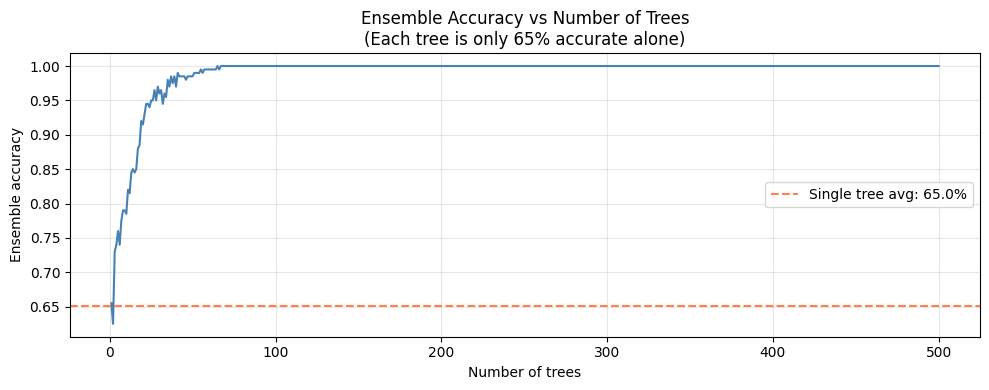

In [3]:
# Why diversity matters — show how averaging reduces error

# Simulate 500 trees each making slightly different errors
n_trees = 500
n_samples = 200
true_labels = np.random.randint(0, 2, n_samples)   # true answers

# Each tree is 65% accurate — not great individually
# But their errors are RANDOM (uncorrelated) because of bagging
individual_accuracies = []
all_predictions = []

for _ in range(n_trees):
    # Simulate a tree that's right 65% of the time
    noise = np.random.rand(n_samples) > 0.65   # 35% chance of wrong prediction
    tree_preds = np.where(noise, 1 - true_labels, true_labels)  # flip 35% labels
    all_predictions.append(tree_preds)
    individual_accuracies.append((tree_preds == true_labels).mean())

# Majority vote across increasing number of trees
all_preds_array = np.array(all_predictions)   # (500, 200)
ensemble_accuracies = []

for n in range(1, n_trees + 1):
    # Take first n trees, majority vote for each sample
    votes = all_preds_array[:n].mean(axis=0)     # average across n trees
    ensemble_pred = (votes >= 0.5).astype(int)   # majority = threshold 0.5
    ensemble_accuracies.append((ensemble_pred == true_labels).mean())

print(f"Single tree average accuracy:  {np.mean(individual_accuracies)*100:.1f}%")
print(f"Ensemble (500 trees) accuracy: {ensemble_accuracies[-1]*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.plot(range(1, n_trees+1), ensemble_accuracies, color='steelblue', linewidth=1.5)
plt.axhline(np.mean(individual_accuracies), color='coral',
            linestyle='--', label=f'Single tree avg: {np.mean(individual_accuracies)*100:.1f}%')
plt.title('Ensemble Accuracy vs Number of Trees\n(Each tree is only 65% accurate alone)')
plt.xlabel('Number of trees')
plt.ylabel('Ensemble accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2 — Generate the Crop Disease Dataset

In [4]:
np.random.seed(42)
n = 1200   # 1200 field readings across Wayanad district

# === Sensor & Environmental Features ===

# Soil pH — rice grows best at 5.5–6.5
# Below or above this range stresses the plant → disease risk
soil_ph = np.random.normal(6.0, 0.8, n).clip(4.0, 8.5)

# Air humidity % — high humidity promotes fungal disease
humidity = np.random.normal(70, 15, n).clip(30, 100)

# Temperature in °C
temperature = np.random.normal(28, 4, n).clip(18, 40)

# Rainfall last 7 days (mm)
rainfall = np.random.exponential(30, n).clip(0, 200)

# Leaf colour score (1=yellowing, 5=healthy green) — visual inspection
leaf_colour = np.random.randint(1, 6, n)

# Nitrogen level in soil (ppm) — low nitrogen = stressed plants
nitrogen = np.random.normal(180, 40, n).clip(60, 300)

# Potassium level (ppm)
potassium = np.random.normal(150, 35, n).clip(50, 280)

# Phosphorus level (ppm)
phosphorus = np.random.normal(40, 12, n).clip(10, 90)

# Days since last pesticide application
days_since_pest = np.random.randint(0, 60, n)

# Water logging score (0=dry, 3=heavily waterlogged)
waterlogging = np.random.randint(0, 4, n)

# Wind speed (km/h) — spreads spores
wind_speed = np.random.normal(12, 5, n).clip(0, 30)

# Crop age (days since planting) — young and old plants are more vulnerable
crop_age = np.random.randint(20, 120, n)

# Previous disease in same field (1=yes, 0=no) — history matters
prev_disease = np.random.choice([0, 1], n, p=[0.65, 0.35])

# === Generate Disease Label ===
# Disease risk based on known agricultural patterns
risk = (
    (humidity > 80).astype(int)           * 3 +  # high humidity = fungal risk
    (leaf_colour <= 2).astype(int)        * 3 +  # yellowing = already sick
    (days_since_pest > 30).astype(int)    * 2 +  # no recent protection
    (waterlogging >= 2).astype(int)       * 2 +  # root rot risk
    (soil_ph < 5.0).astype(int)           * 2 +  # acidic soil stress
    (soil_ph > 7.5).astype(int)           * 1 +  # alkaline soil stress
    (nitrogen < 120).astype(int)          * 2 +  # nitrogen deficiency
    (temperature > 33).astype(int)        * 1 +  # heat stress
    (prev_disease == 1).astype(int)       * 2    # history of disease
)

prob_disease = (risk / risk.max()) * 0.85 + 0.05  # scale to 5%-90%
diseased = (np.random.rand(n) < prob_disease).astype(int)

# === Build DataFrame ===
df = pd.DataFrame({
    'soil_ph':          soil_ph.round(2),
    'humidity_pct':     humidity.round(1),
    'temperature_c':    temperature.round(1),
    'rainfall_7d_mm':   rainfall.round(1),
    'leaf_colour':      leaf_colour,
    'nitrogen_ppm':     nitrogen.round(1),
    'potassium_ppm':    potassium.round(1),
    'phosphorus_ppm':   phosphorus.round(1),
    'days_since_pest':  days_since_pest,
    'waterlogging':     waterlogging,
    'wind_speed_kmh':   wind_speed.round(1),
    'crop_age_days':    crop_age,
    'prev_disease':     prev_disease,
    'diseased':         diseased          # target: 1=diseased, 0=healthy
})

print("Dataset shape:", df.shape)
print(f"\nDisease rate: {df['diseased'].mean()*100:.1f}%")
print(f"Diseased fields:  {df['diseased'].sum()}")
print(f"Healthy fields:   {(df['diseased']==0).sum()}")
df.head()

Dataset shape: (1200, 14)

Disease rate: 35.1%
Diseased fields:  421
Healthy fields:   779


,soil_ph,humidity_pct,temperature_c,rainfall_7d_mm,leaf_colour,nitrogen_ppm,potassium_ppm,phosphorus_ppm,days_since_pest,waterlogging,wind_speed_kmh,crop_age_days,prev_disease,diseased
0,6.40,71.9,25.1,8.9,1,225.2,148.8,27.1,30,0,5.3,116,1,0
1,5.89,63.6,28.7,7.5,4,186.3,146.9,29.7,36,0,3.2,52,0,0
2,6.52,71.8,25.8,4.5,4,173.4,207.6,37.3,40,2,17.5,26,0,1
3,7.22,78.1,26.9,58.8,2,179.7,203.2,40.5,40,2,15.3,41,1,0
4,5.81,70.7,34.7,20.8,1,178.8,197.3,49.9,33,0,15.5,24,0,1


## Step 3 — EDA

In [5]:
# Basic checks
print("Missing values:")
print(df.isnull().sum())
print("\nStats:")
df.describe().round(2)

Missing values:
soil_ph            0
humidity_pct       0
temperature_c      0
rainfall_7d_mm     0
leaf_colour        0
nitrogen_ppm       0
potassium_ppm      0
phosphorus_ppm     0
days_since_pest    0
waterlogging       0
wind_speed_kmh     0
crop_age_days      0
prev_disease       0
diseased           0
dtype: int64

Stats:


,soil_ph,humidity_pct,temperature_c,rainfall_7d_mm,leaf_colour,nitrogen_ppm,potassium_ppm,phosphorus_ppm,days_since_pest,waterlogging,wind_speed_kmh,crop_age_days,prev_disease,diseased
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,6.03,70.26,28.07,29.98,2.94,181.34,150.15,39.56,29.49,1.46,12.05,69.80,0.35,0.35
std,0.79,14.41,4.06,29.51,1.40,39.27,35.58,11.92,16.99,1.10,4.99,28.50,0.48,0.48
min,4.00,30.00,18.00,0.00,1.00,60.00,50.20,10.00,0.00,0.00,0.00,20.00,0.00,0.00
25%,5.50,60.38,25.20,8.67,2.00,154.00,126.35,31.38,15.00,0.00,8.70,44.00,0.00,0.00
50%,6.04,70.20,28.10,19.90,3.00,181.00,150.15,39.55,29.00,1.00,12.10,70.00,0.00,0.00
75%,6.54,80.10,30.80,41.80,4.00,208.12,174.90,47.60,44.00,2.00,15.40,94.25,1.00,1.00
max,8.50,100.00,40.00,200.00,5.00,300.00,274.40,76.90,59.00,3.00,29.10,119.00,1.00,1.00


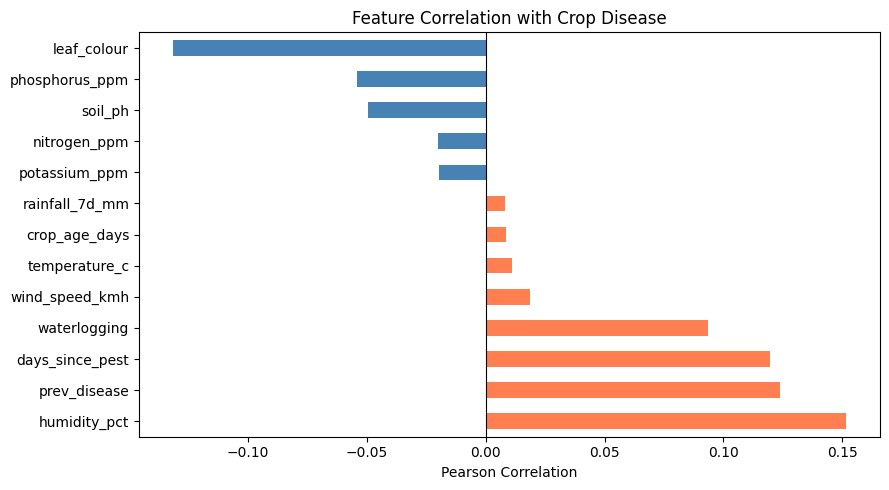

humidity_pct       0.152
prev_disease       0.124
days_since_pest    0.120
waterlogging       0.094
wind_speed_kmh     0.019
temperature_c      0.011
crop_age_days      0.009
rainfall_7d_mm     0.008
potassium_ppm     -0.019
nitrogen_ppm      -0.020
soil_ph           -0.049
phosphorus_ppm    -0.054
leaf_colour       -0.132
Name: diseased, dtype: float64


In [6]:
# Feature correlations with disease
corr = df.corr()['diseased'].drop('diseased').sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = ['coral' if c > 0 else 'steelblue' for c in corr]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Crop Disease')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()
print(corr.round(3))

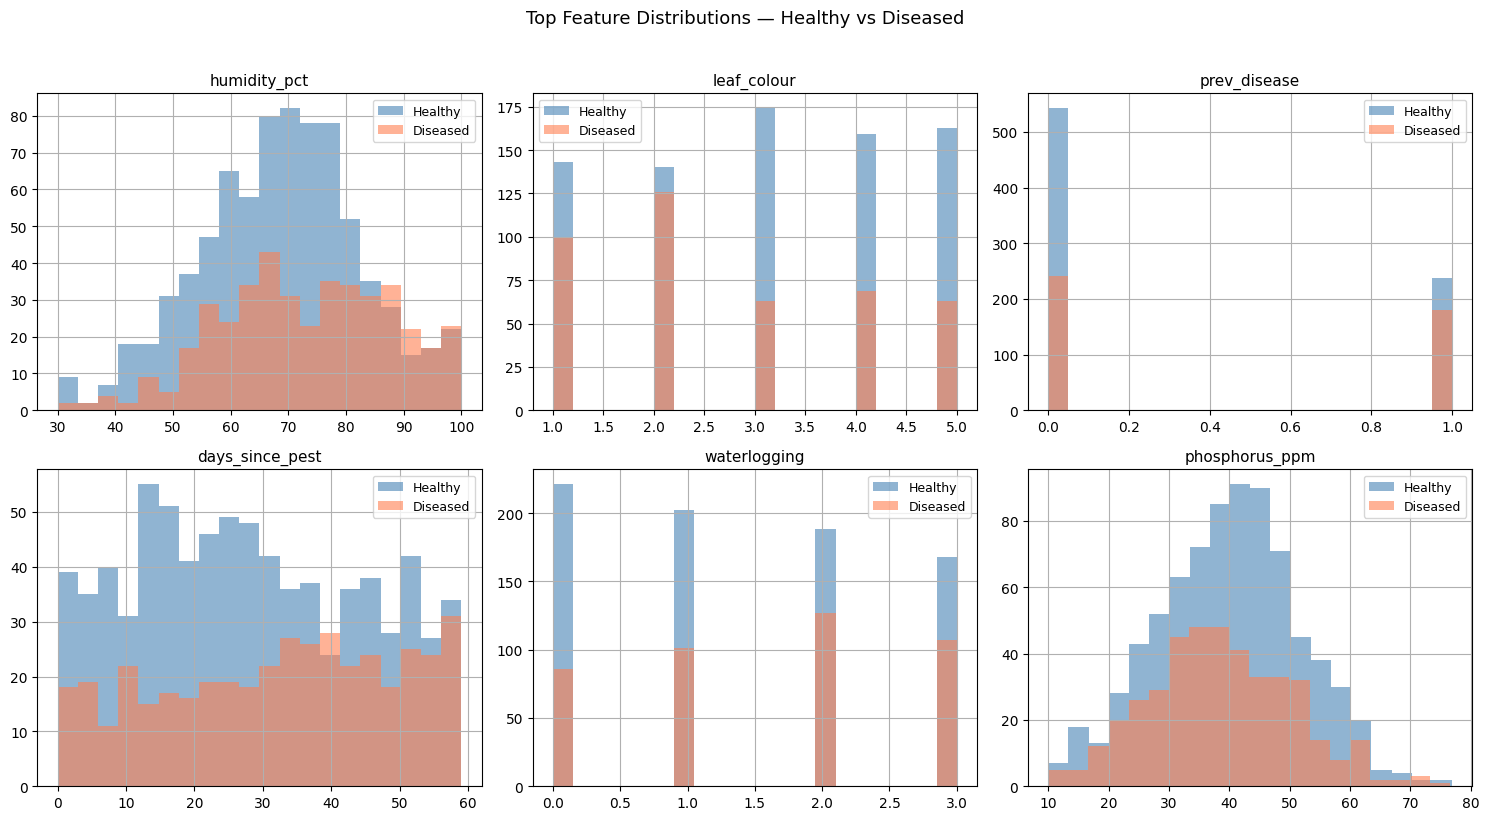

In [7]:
# Distribution of top features by disease status
top_features = corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top_features):
    df[df['diseased']==0][feat].hist(ax=ax, alpha=0.6, color='steelblue',
                                      label='Healthy', bins=20)
    df[df['diseased']==1][feat].hist(ax=ax, alpha=0.6, color='coral',
                                      label='Diseased', bins=20)
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Top Feature Distributions — Healthy vs Diseased', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Step 4 — Prepare Data

In [8]:
X = df.drop(columns=['diseased'])
y = df['diseased']

# Stratified split — preserve disease rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} field readings")
print(f"Test:  {X_test.shape[0]} field readings")
print(f"\nDisease rate — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")
print("\nNote: NO scaling needed — Random Forest is tree-based, not distance-based")

Train: 960 field readings
Test:  240 field readings

Disease rate — Train: 35.1% | Test: 35.0%

Note: NO scaling needed — Random Forest is tree-based, not distance-based


## Step 5 — Compare: Single Tree vs Bagging vs Random Forest

In [9]:
# This comparison proves WHY Random Forest is better
# We go from worst to best: Single Tree → Bagging → Random Forest

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# --- 1. Single Decision Tree (overfits, unstable) ---
single_tree = DecisionTreeClassifier(max_depth=8, random_state=42)
single_tree.fit(X_train, y_train)
st_pred = single_tree.predict(X_test)
st_prob = single_tree.predict_proba(X_test)[:, 1]
results['Single Tree'] = {
    'Train Acc': single_tree.score(X_train, y_train),
    'Test Acc':  single_tree.score(X_test, y_test),
    'F1':        f1_score(y_test, st_pred),
    'AUC':       roc_auc_score(y_test, st_prob),
    'CV F1':     cross_val_score(single_tree, X_train, y_train, cv=cv, scoring='f1').mean()
}

# --- 2. Bagging (bootstrap only, no feature randomness) ---
# max_features=None means each tree considers ALL features → less diversity
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    bootstrap=True,        # sample rows with replacement
    max_features=1.0,      # use ALL features (no feature randomness)
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
bag_pred = bagging.predict(X_test)
bag_prob = bagging.predict_proba(X_test)[:, 1]
results['Bagging (100 trees, all features)'] = {
    'Train Acc': bagging.score(X_train, y_train),
    'Test Acc':  bagging.score(X_test, y_test),
    'F1':        f1_score(y_test, bag_pred),
    'AUC':       roc_auc_score(y_test, bag_prob),
    'CV F1':     cross_val_score(bagging, X_train, y_train, cv=cv, scoring='f1').mean()
}

# --- 3. Random Forest (bootstrap + feature randomness) ---
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',    # sqrt(13) ≈ 3-4 features per split
    oob_score=True,         # use out-of-bag samples for free validation
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
results['Random Forest (100 trees, sqrt features)'] = {
    'Train Acc': rf.score(X_train, y_train),
    'Test Acc':  rf.score(X_test, y_test),
    'F1':        f1_score(y_test, rf_pred),
    'AUC':       roc_auc_score(y_test, rf_prob),
    'CV F1':     cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1').mean()
}

# Print comparison table
results_df = pd.DataFrame(results).T.round(4)
print("=== Model Comparison ===")
print(results_df.to_string())
print("\nOOB Score (Random Forest free validation):", round(rf.oob_score_, 4))
print("\nWhat to notice:")
print("  Single Tree: high train acc, lower test acc → overfitting")
print("  Bagging: better test acc → bootstrap helps")
print("  Random Forest: best test acc → feature randomness adds further diversity")

=== Model Comparison ===
                                          Train Acc  Test Acc      F1     AUC   CV F1
Single Tree                                  0.9021    0.5833  0.3827  0.5383  0.4264
Bagging (100 trees, all features)            1.0000    0.6083  0.2985  0.5943  0.4227
Random Forest (100 trees, sqrt features)     1.0000    0.6208  0.2835  0.5797  0.3914

OOB Score (Random Forest free validation): 0.6875

What to notice:
  Single Tree: high train acc, lower test acc → overfitting
  Bagging: better test acc → bootstrap helps
  Random Forest: best test acc → feature randomness adds further diversity


## Step 6 — Effect of Number of Trees

/Users/arwindhcn/my-ml-journey/ml-env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/arwindhcn/my-ml-journey/ml-env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/arwindhcn/my-ml-journey/ml-env/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


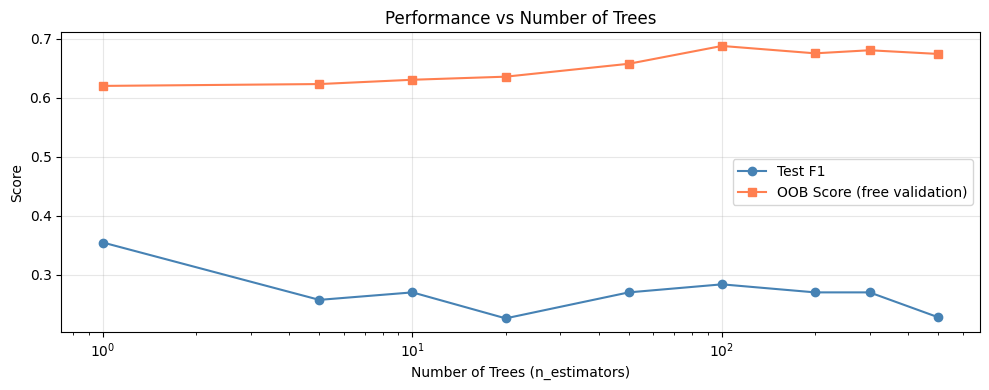

What the plot shows:
  1-50 trees: big improvement with each addition
  100-200 trees: good performance, diminishing returns
  300+ trees: almost no improvement, just slower
  Rule of thumb: 100-300 trees is usually enough


In [10]:
# How many trees do we actually need?
# After a certain point, adding more trees gives diminishing returns
# But too few trees = unstable predictions

n_tree_values = [1, 5, 10, 20, 50, 100, 200, 300, 500]
test_f1s  = []
oob_scores = []

for n in n_tree_values:
    rf_n = RandomForestClassifier(
        n_estimators=n,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_n.fit(X_train, y_train)
    preds = rf_n.predict(X_test)
    test_f1s.append(f1_score(y_test, preds))
    oob_scores.append(rf_n.oob_score_)

plt.figure(figsize=(10, 4))
plt.plot(n_tree_values, test_f1s,   color='steelblue', marker='o', label='Test F1')
plt.plot(n_tree_values, oob_scores, color='coral',     marker='s', label='OOB Score (free validation)')
plt.title('Performance vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Score')
plt.xscale('log')   # log scale because early gains are steep
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("What the plot shows:")
print("  1-50 trees: big improvement with each addition")
print("  100-200 trees: good performance, diminishing returns")
print("  300+ trees: almost no improvement, just slower")
print("  Rule of thumb: 100-300 trees is usually enough")

## Step 7 — Hyperparameter Tuning with GridSearchCV

In [12]:
# Tune the most impactful Random Forest parameters

param_grid = {
    'n_estimators':     [100, 200, 300],   # more trees = more stable
    'max_features':     ['sqrt', 'log2'],   # sqrt=default, log2=fewer features per split
    # sqrt(13)≈3.6, log2(13)≈3.7 — similar for 13 features
    'max_depth':        [None, 10, 20],     # None=full depth (usually best for RF)
    'min_samples_leaf': [1, 2, 4],          # larger = smoother boundaries
}

# Total: 3 × 2 × 3 × 3 = 54 combinations × 5 folds = 270 models
grid_search = GridSearchCV(
    RandomForestClassifier(oob_score=False, random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters:
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 1
  n_estimators: 100

Best CV F1: 0.4030


## Step 8 — Final Model Evaluation

In [13]:
best_rf = grid_search.best_estimator_

y_pred_final = best_rf.predict(X_test)
y_prob_final = best_rf.predict_proba(X_test)[:, 1]

print("=== Final Random Forest — Classification Report ===")
print(classification_report(y_test, y_pred_final,
                             target_names=['Healthy (0)', 'Diseased (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"Train accuracy: {best_rf.score(X_train, y_train)*100:.1f}%")
print(f"Test accuracy:  {best_rf.score(X_test, y_test)*100:.1f}%")
print(f"Overfit gap:    {(best_rf.score(X_train, y_train) - best_rf.score(X_test, y_test))*100:.1f}%")

=== Final Random Forest — Classification Report ===
              precision    recall  f1-score   support

 Healthy (0)       0.67      0.83      0.74       156
Diseased (1)       0.42      0.23      0.29        84

    accuracy                           0.62       240
   macro avg       0.54      0.53      0.52       240
weighted avg       0.58      0.62      0.58       240

ROC-AUC: 0.5802
Train accuracy: 100.0%
Test accuracy:  62.1%
Overfit gap:    37.9%


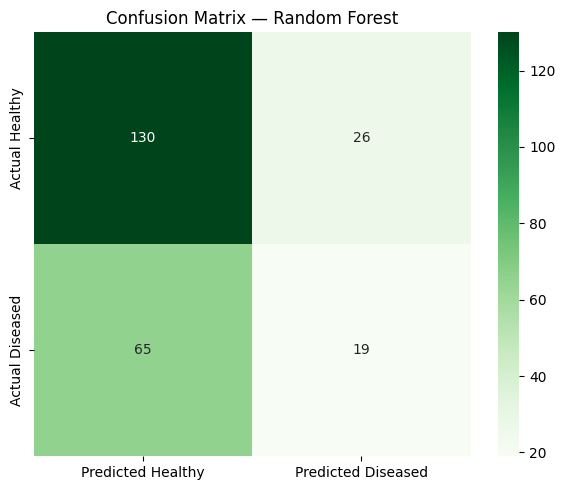

True Negatives  (healthy, correctly cleared):   130
False Positives (healthy, wrongly sprayed):     26  ← unnecessary pesticide cost
False Negatives (diseased, missed):             65  ← field lost, ₹2-4L damage
True Positives  (diseased, caught early):       19  ← intervention saves the crop

Catch rate: 19/84 diseased fields detected (22.6%)


In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Healthy', 'Predicted Diseased'],
            yticklabels=['Actual Healthy', 'Actual Diseased'])
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (healthy, correctly cleared):   {tn}")
print(f"False Positives (healthy, wrongly sprayed):     {fp}  ← unnecessary pesticide cost")
print(f"False Negatives (diseased, missed):             {fn}  ← field lost, ₹2-4L damage")
print(f"True Positives  (diseased, caught early):       {tp}  ← intervention saves the crop")
print(f"\nCatch rate: {tp}/{fn+tp} diseased fields detected ({tp/(fn+tp)*100:.1f}%)")

## Step 9 — Feature Importance (Two Methods)

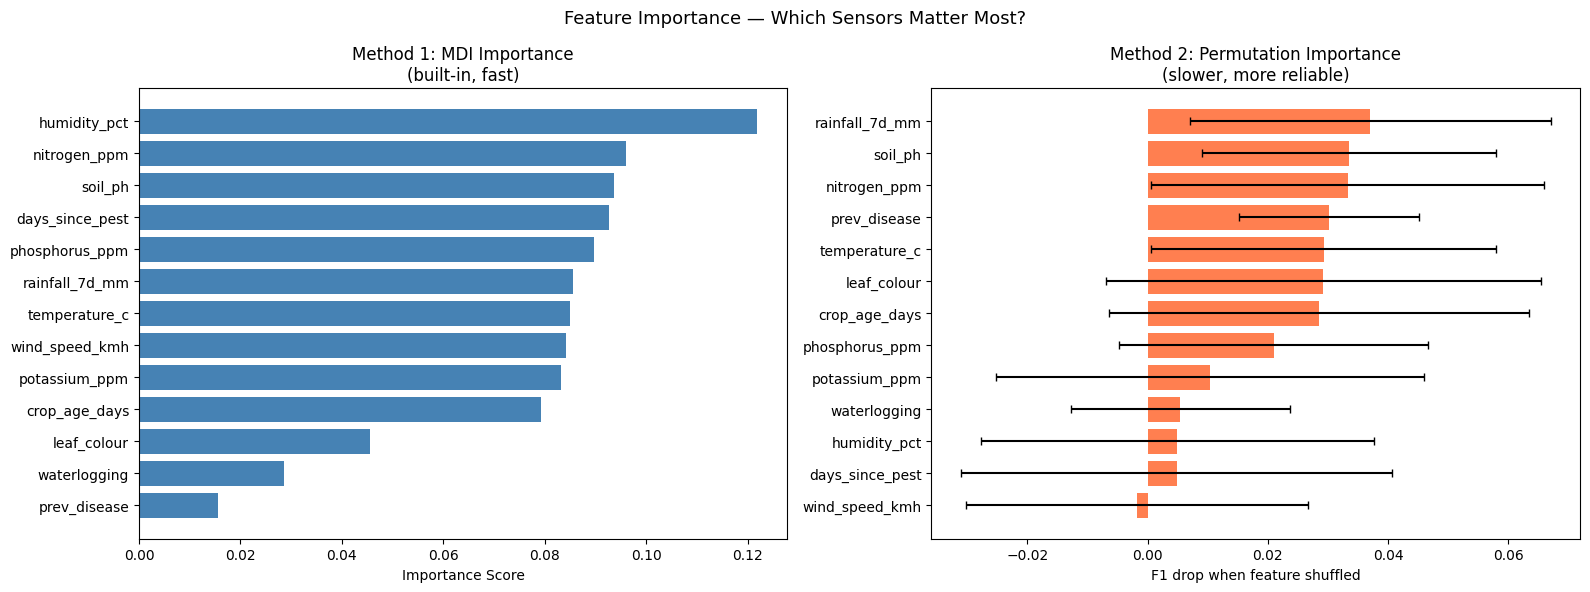

Top 5 features by MDI:
        Feature  MDI Importance
   humidity_pct          0.1217
   nitrogen_ppm          0.0960
        soil_ph          0.0936
days_since_pest          0.0926
 phosphorus_ppm          0.0896

Top 5 features by Permutation:
       Feature  Perm Importance
rainfall_7d_mm           0.0371
       soil_ph           0.0335
  nitrogen_ppm           0.0333
  prev_disease           0.0302
 temperature_c           0.0293


In [15]:
# Extract the best performing model from your Grid Search
# METHOD 1: Built-in feature importance (Mean Decrease in Impurity)
# How much each feature reduces Gini impurity across all trees and all splits
# Fast but can be biased toward high-cardinality features

mdi_importance = pd.DataFrame({
    'Feature': X.columns,
    'MDI Importance': best_rf.feature_importances_
}).sort_values('MDI Importance', ascending=False)

# METHOD 2: Permutation Importance
# Shuffle one feature at a time → measure how much accuracy drops
# If shuffling a feature destroys accuracy → that feature was crucial
# More reliable than MDI — doesn't favour numeric/high cardinality features

perm_imp = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,     # shuffle each feature 10 times and average
    random_state=42,
    scoring='f1'
)

perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Perm Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Perm Importance', ascending=False)

# Side by side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(mdi_importance['Feature'], mdi_importance['MDI Importance'],
         color='steelblue')
ax1.set_title('Method 1: MDI Importance\n(built-in, fast)')
ax1.set_xlabel('Importance Score')
ax1.invert_yaxis()

ax2.barh(perm_importance['Feature'], perm_importance['Perm Importance'],
         xerr=perm_importance['Std'], color='coral', capsize=3)
ax2.set_title('Method 2: Permutation Importance\n(slower, more reliable)')
ax2.set_xlabel('F1 drop when feature shuffled')
ax2.invert_yaxis()

plt.suptitle('Feature Importance — Which Sensors Matter Most?', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 5 features by MDI:")
print(mdi_importance.head(5)[['Feature','MDI Importance']].round(4).to_string(index=False))
print("\nTop 5 features by Permutation:")
print(perm_importance.head(5)[['Feature','Perm Importance']].round(4).to_string(index=False))

## Step 10 — ROC Curve (Comparing All 3 Models)

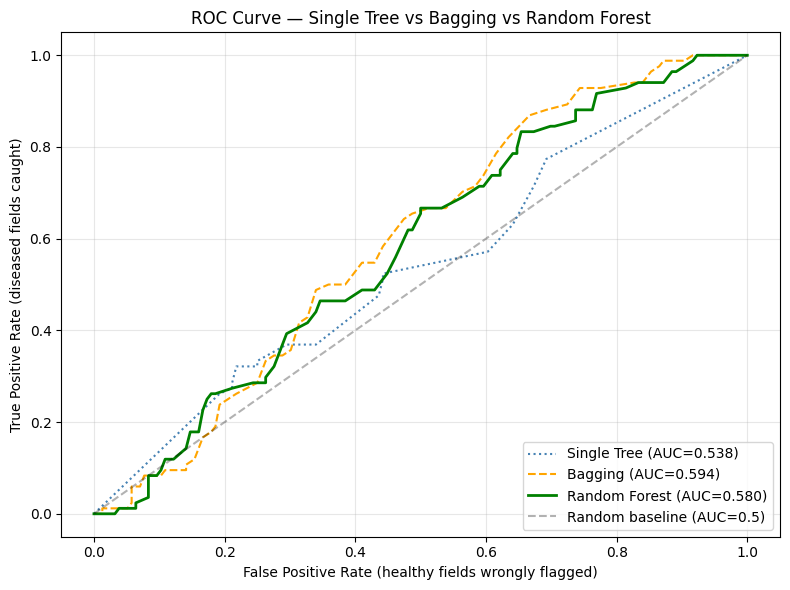

In [16]:
# ROC curve shows performance across ALL thresholds at once
# Area Under the Curve (AUC) = single number summary
# AUC=0.5 → random guessing, AUC=1.0 → perfect

plt.figure(figsize=(8, 6))

# Single tree
fpr, tpr, _ = roc_curve(y_test, single_tree.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label=f'Single Tree (AUC={roc_auc_score(y_test, single_tree.predict_proba(X_test)[:,1]):.3f})',
         color='steelblue', linestyle=':')

# Bagging
fpr, tpr, _ = roc_curve(y_test, bag_prob)
plt.plot(fpr, tpr, label=f'Bagging (AUC={roc_auc_score(y_test, bag_prob):.3f})',
         color='orange', linestyle='--')

# Random Forest (best)
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
plt.plot(fpr, tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_final):.3f})',
         color='green', linewidth=2)

# Diagonal = random guess baseline
plt.plot([0,1],[0,1], 'k--', alpha=0.3, label='Random baseline (AUC=0.5)')

plt.xlabel('False Positive Rate (healthy fields wrongly flagged)')
plt.ylabel('True Positive Rate (diseased fields caught)')
plt.title('ROC Curve — Single Tree vs Bagging vs Random Forest')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11 — Threshold Tuning for Agriculture Context

In [ ]:
# In agriculture:
# - Missing a diseased field (FN) → disease spreads → crop loss → ₹2-4L per farmer
# - False alarm (FP) → unnecessary pesticide spray → ₹3,000-5,000 cost
# - Missing a disease is ~500x more costly than a false alarm
# → We should aggressively LOWER the threshold

thresholds   = np.arange(0.10, 0.90, 0.05)
recalls, precisions, f1s = [], [], []
fn_costs, fp_costs, total_costs = [], [], []

COST_FN = 300000   # ₹3L average crop loss per missed diseased field
COST_FP = 4000     # ₹4k pesticide spray for unnecessary treatment

for thresh in thresholds:
    y_t = (y_prob_final >= thresh).astype(int)
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    f1s.append(f1_score(y_test, y_t, zero_division=0))

    cm_t = confusion_matrix(y_test, y_t)
    fn = cm_t[1][0]    # missed diseases
    fp = cm_t[0][1]    # false alarms

    fn_costs.append(fn * COST_FN)
    fp_costs.append(fp * COST_FP)
    total_costs.append(fn * COST_FN + fp * COST_FP)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds, recalls,    color='coral',     label='Recall (catch rate)',  marker='o', ms=3)
ax1.plot(thresholds, precisions, color='steelblue', label='Precision',            marker='o', ms=3)
ax1.plot(thresholds, f1s,        color='green',     label='F1',                   marker='s', ms=3)
ax1.axvline(0.5,  color='gray',  linestyle='--', alpha=0.7, label='Default (0.5)')
ax1.axvline(0.3,  color='black', linestyle=':',  alpha=0.8, label='Conservative (0.3)')
ax1.set_title('Metrics vs Threshold')
ax1.set_xlabel('Threshold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(thresholds, [c/1e6 for c in fn_costs],    color='red',    linewidth=2, label='Crop loss cost (FN) ₹L')
ax2.plot(thresholds, [c/1e6 for c in fp_costs],    color='orange', linewidth=2, label='Spray cost (FP) ₹L')
ax2.plot(thresholds, [c/1e6 for c in total_costs], color='black',  linewidth=2, linestyle='--', label='Total cost ₹L')
best_thresh_idx = np.argmin(total_costs)
ax2.axvline(thresholds[best_thresh_idx], color='green', linestyle='-.',
            label=f'Optimal threshold: {thresholds[best_thresh_idx]:.2f}')
ax2.set_title('Business Cost vs Threshold (₹ Lakhs)')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Total Cost (₹ Lakhs)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_threshold = thresholds[best_thresh_idx]
print(f"Optimal threshold (minimum total cost): {optimal_threshold:.2f}")
print(f"Total cost at 0.50: ₹{total_costs[list(thresholds).index(min(thresholds, key=lambda x: abs(x-0.5)))]/1e5:.1f}L")
print(f"Total cost at {optimal_threshold:.2f}: ₹{total_costs[best_thresh_idx]/1e5:.1f}L")

## Step 12 — Cross-Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== 5-Fold Cross-Validation — Random Forest ===")
for metric in ['accuracy', 'f1', 'roc_auc']:
    scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring=metric)
    print(f"  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}"
          f"  | {[round(s,3) for s in scores]}")

print("\nCompare this std to the single tree — RF is much more stable")

## Step 13 — Predict for New Field Readings

In [ ]:
# Three fields in Wayanad submit their sensor readings this morning

new_fields = pd.DataFrame([
    # All features in order
    {'soil_ph': 5.2, 'humidity_pct': 88, 'temperature_c': 32, 'rainfall_7d_mm': 85,
     'leaf_colour': 1, 'nitrogen_ppm': 95, 'potassium_ppm': 120, 'phosphorus_ppm': 28,
     'days_since_pest': 45, 'waterlogging': 3, 'wind_speed_kmh': 18,
     'crop_age_days': 55, 'prev_disease': 1},    # Field A — multiple risk factors

    {'soil_ph': 6.2, 'humidity_pct': 55, 'temperature_c': 27, 'rainfall_7d_mm': 20,
     'leaf_colour': 5, 'nitrogen_ppm': 200, 'potassium_ppm': 160, 'phosphorus_ppm': 45,
     'days_since_pest': 10, 'waterlogging': 0, 'wind_speed_kmh': 8,
     'crop_age_days': 40, 'prev_disease': 0},    # Field B — healthy profile

    {'soil_ph': 6.8, 'humidity_pct': 74, 'temperature_c': 29, 'rainfall_7d_mm': 45,
     'leaf_colour': 3, 'nitrogen_ppm': 155, 'potassium_ppm': 140, 'phosphorus_ppm': 38,
     'days_since_pest': 22, 'waterlogging': 1, 'wind_speed_kmh': 13,
     'crop_age_days': 70, 'prev_disease': 1},    # Field C — borderline
])

probs = best_rf.predict_proba(new_fields)[:, 1]

# Use the cost-optimal threshold we found
alerts = ['🚨 ALERT — Spray immediately' if p >= optimal_threshold
          else '✅ Healthy — Monitor normally' for p in probs]

print("=== Wayanad District — Morning Field Report ===")
print(f"{'Field':<8} {'P(Disease)':>12} {'Action':<30}")
print("-" * 55)
for name, prob, alert in zip(['Field A', 'Field B', 'Field C'], probs, alerts):
    print(f"{name:<8} {prob*100:>11.1f}%  {alert}")

print(f"\nThreshold used: {optimal_threshold:.2f} (cost-optimised for agriculture context)")
print("\nTop sensor to watch (from feature importance):")
print(f"  {perm_importance.iloc[0]['Feature']} — if this reads high, disease risk jumps significantly")

## Final Summary

### What we built
A Random Forest that predicts crop disease from 13 field sensor readings — helping farmers in Wayanad intervene before losses occur.

### The progression from worst to best

| Model | What it adds | Why it helps |
|---|---|---|
| Single Decision Tree | Just one tree | Overfits, unstable |
| Bagging | Bootstrap row sampling | Reduces variance |
| **Random Forest** | + Feature randomness per split | Forces diversity, best performance |

### Key decisions and why

| Decision | What | Why |
|---|---|---|
| No scaling | Skipped StandardScaler | Tree-based, not distance-based |
| `oob_score=True` | Free validation with OOB | No extra data needed for quick check |
| `max_features='sqrt'` | ~3-4 features per split | Forces tree diversity |
| Permutation importance | Alongside MDI importance | More reliable, not biased |
| Cost-optimal threshold | Below 0.5 | Missing disease is 75x costlier than false alarm |

### Random Forest Pros & Cons

| Pros | Cons |
|---|---|
| Rarely overfits | Slower than single tree |
| Works well out of the box | Not interpretable (can't print the rules) |
| Handles missing values reasonably | Feature importance can mislead |
| Built-in OOB validation | Memory intensive (stores all 100-500 trees) |
| Feature importance built-in | Black box — no single rule to explain |

### The core insight to remember years later
**Diversity is the secret.** Each tree is weak and wrong in its own way.  
But when you combine 500 diverse trees, the random errors cancel out and the true signal survives.  
This is the **ensemble principle** — and it's the foundation of the most powerful algorithms in ML (Gradient Boosting, XGBoost, LightGBM in later chapters).

## Practice Task — Hospital Readmission Prediction
### Government Hospital, Thiruvananthapuram

In [ ]:
# A government hospital wants to predict which patients will be readmitted
# within 30 days of discharge — so they can schedule follow-up calls

np.random.seed(99)
n = 1000

age            = np.random.randint(18, 85, n)
num_diagnoses  = np.random.randint(1, 10, n)
num_procedures = np.random.randint(0, 8, n)
num_medications= np.random.randint(1, 15, n)
days_in_hosp   = np.random.randint(1, 14, n)
prior_visits   = np.random.randint(0, 6, n)
a1c_result     = np.random.choice([0,1,2], n, p=[0.5,0.3,0.2])  # 0=normal,1=high,2=very high
discharge_type = np.random.choice([0,1,2], n, p=[0.6,0.3,0.1])  # 0=home,1=care,2=against advice
num_lab_tests  = np.random.randint(1, 20, n)
insulin_used   = np.random.choice([0,1], n, p=[0.6,0.4])

risk = (
    (age > 65).astype(int)             * 2 +
    (num_diagnoses > 6).astype(int)    * 2 +
    (prior_visits > 3).astype(int)     * 3 +
    (a1c_result == 2).astype(int)      * 2 +
    (discharge_type == 2).astype(int)  * 3 +
    (days_in_hosp > 7).astype(int)     * 1 +
    (num_medications > 10).astype(int) * 1
)

prob_readmit = (risk / risk.max()) * 0.8 + 0.05
readmitted = (np.random.rand(n) < prob_readmit).astype(int)

hospital_df = pd.DataFrame({
    'age': age, 'num_diagnoses': num_diagnoses,
    'num_procedures': num_procedures, 'num_medications': num_medications,
    'days_in_hospital': days_in_hosp, 'prior_visits': prior_visits,
    'a1c_result': a1c_result, 'discharge_type': discharge_type,
    'num_lab_tests': num_lab_tests, 'insulin_used': insulin_used,
    'readmitted': readmitted
})

print("Hospital dataset shape:", hospital_df.shape)
print(f"Readmission rate: {hospital_df['readmitted'].mean()*100:.1f}%")
hospital_df.head()

In [ ]:
# YOUR CODE HERE

# Step 1: Split into X and y
X_h = 
y_h = 

# Step 2: Train/test split (stratified, 80/20)


# Step 3: Compare Single Tree vs Bagging vs Random Forest
# Print Train Acc, Test Acc, F1, AUC for all three


# Step 4: Plot performance vs n_estimators (1 to 300)
# At what n does adding more trees stop helping?


# Step 5: GridSearchCV to tune n_estimators, max_features, min_samples_leaf


# Step 6: Print classification report + confusion matrix for best model


# Step 7: Plot both MDI and Permutation importance
# Which feature matters most — age or prior_visits?


# Step 8: Threshold tuning
# Missing a readmission (FN) = patient deteriorates at home = serious
# False alarm (FP) = unnecessary phone call = minor inconvenience
# What threshold makes sense for a hospital?


# Step 9: Predict for these 2 patients at discharge
new_patients = pd.DataFrame([
    {'age': 72, 'num_diagnoses': 8, 'num_procedures': 3, 'num_medications': 12,
     'days_in_hospital': 9, 'prior_visits': 4, 'a1c_result': 2,
     'discharge_type': 0, 'num_lab_tests': 15, 'insulin_used': 1},  # high risk
    {'age': 34, 'num_diagnoses': 2, 'num_procedures': 1, 'num_medications': 3,
     'days_in_hospital': 2, 'prior_visits': 0, 'a1c_result': 0,
     'discharge_type': 0, 'num_lab_tests': 5,  'insulin_used': 0},  # low risk
])
# Should the hospital schedule follow-up calls for either patient?